# Apple Stock

### Introduction:

We are going to use Apple's stock price.


### Step 1. Import the necessary libraries

In [1]:
import pandas as pd
import numpy as np

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/09_Time_Series/Apple_Stock/appl_1980_2014.csv)

In [2]:
data = pd.read_csv('https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/09_Time_Series/Apple_Stock/appl_1980_2014.csv',sep=',')

### Step 3. Assign it to a variable apple

In [3]:
#복사본 만들기
apple = data.copy()

### Step 4.  Check out the type of the columns

In [4]:
apple.dtypes

,0
Date,object
Open,float64
High,float64
Low,float64
Close,float64
Volume,int64
Adj Close,float64


### Step 5. Transform the Date column as a datetime type

In [7]:
#to_datetime = 문자열을 날짜 타입으로 바꿔주는 함수
apple_date = pd.to_datetime(apple.Date)

### Step 6.  Set the date as the index

In [8]:
#set_index를 통해 데이터 컬럼을 행의 기준 즉, 인덱스로 바꿔줌
apple = apple.set_index(apple_date)

### Step 7.  Is there any duplicate dates?

In [14]:
#중복 개수 0개
apple.index.duplicated().sum()

np.int64(0)

### Step 8.  Ops...it seems the index is from the most recent date. Make the first entry the oldest date.

In [17]:
# 과거부터 현재까지 시간순 인덱싱
apple = apple.sort_index(ascending=True)
apple.head()

,Date,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,,
1980-12-12,1980-12-12,28.75,28.87,28.75,28.75,117258400,0.45
1980-12-15,1980-12-15,27.38,27.38,27.25,27.25,43971200,0.42
1980-12-16,1980-12-16,25.37,25.37,25.25,25.25,26432000,0.39
1980-12-17,1980-12-17,25.87,26.00,25.87,25.87,21610400,0.40
1980-12-18,1980-12-18,26.63,26.75,26.63,26.63,18362400,0.41


### Step 9. Get the last business day of each month

In [18]:
#BM = 주기 (월 말)
#주기를 월 단위로 다시 resampling함 (월 말을 기준으로 데이터를 resampling)
# last를 통해 마지막 영업일 데이터만 가져옴
apple_month = apple.resample('BM').last()
apple_month

/tmp/ipykernel_3750/4074304278.py:1: FutureWarning: 'BM' is deprecated and will be removed in a future version, please use 'BME' instead.
  apple_month = apple.resample('BM').last()


,Date,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,,
1980-12-31,1980-12-31,34.25,34.25,34.13,34.13,8937600,0.53
1981-01-30,1981-01-30,28.50,28.50,28.25,28.25,11547200,0.44
1981-02-27,1981-02-27,26.50,26.75,26.50,26.50,3690400,0.41
1981-03-31,1981-03-31,24.75,24.75,24.50,24.50,3998400,0.38
1981-04-30,1981-04-30,28.38,28.62,28.38,28.38,3152800,0.44
...,...,...,...,...,...,...,...
2014-03-31,2014-03-31,539.23,540.81,535.93,536.74,42167300,76.25
2014-04-30,2014-04-30,592.64,599.43,589.80,590.09,114160200,83.83
2014-05-30,2014-05-30,637.98,644.17,628.90,633.00,141005200,90.43


### Step 10.  What is the difference in days between the first day and the oldest

In [19]:
(apple.index.max() - apple.index.min()).days

12261

### Step 11.  How many months in the data we have?

In [20]:
#월 별 데이터 개수
len(apple_month)

404

### Step 12. Plot the 'Adj Close' value. Set the size of the figure to 13.5 x 9 inches

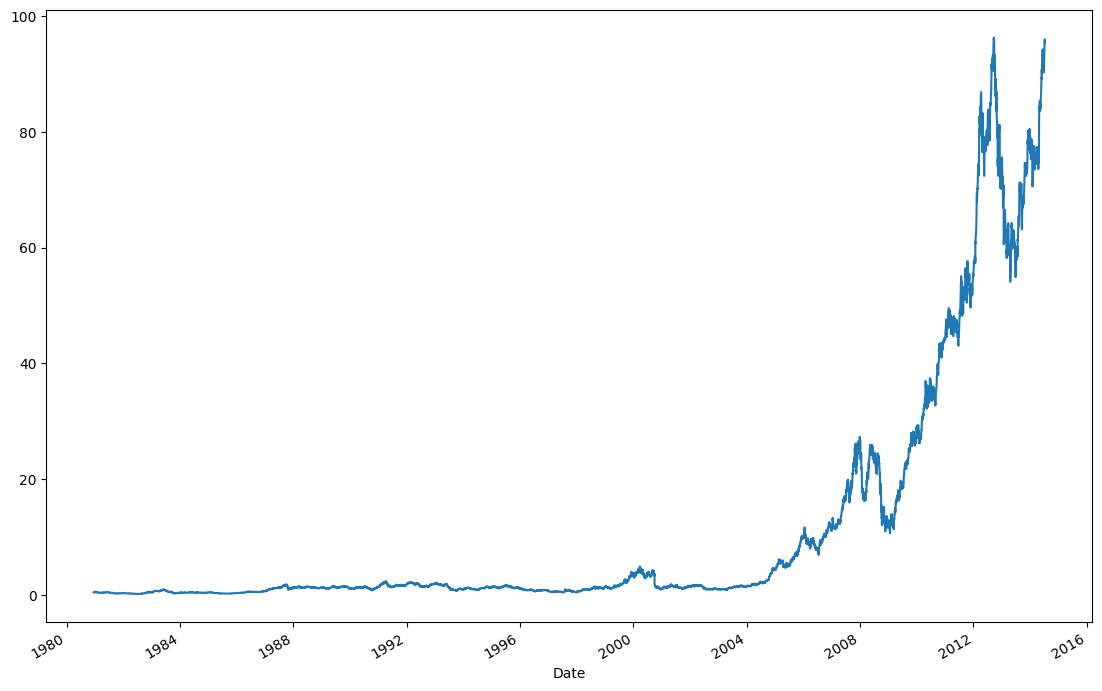

In [21]:
import matplotlib.pyplot as plt
%matplotlib inline

apple['Adj Close'].plot(figsize=(13.5,9))
plt.show()